<a href="https://colab.research.google.com/github/JoEl-11/Assessment-2/blob/main/Customer_Churn_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction
### Complete Case Study

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


## Load Dataset

In [2]:
train_df=pd.read_csv("Training_data.csv")
test_df=pd.read_csv("Testing_data.csv")
train_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


## Exploratory Data Analysis

### Dataset Shape

In [3]:
print(train_df.shape)
print(test_df.shape)

(5634, 21)
(1409, 21)


### Dataset Information

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


### Summary Statistics

In [5]:
train_df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,5634,5465,5634.000000,5634,5634,5634.000000,5634,5634,5634,5465,...,5634,5634,5634,5634,5634,5634,5634,5240.000000,5353,5634
unique,5634,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,5040,2
top,3402-XRIUO,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,2744,NaN,2890,3960,NaN,5081,2701,2486,2720,...,2485,2782,2244,2232,3094,3350,1892,NaN,9,4130
mean,NaN,NaN,0.159744,NaN,NaN,32.606851,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.102052,NaN,NaN
std,NaN,NaN,0.366401,NaN,NaN,24.614976,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.056443,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.800000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.650000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,56.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.050000,NaN,NaN


### Missing Values

In [6]:
train_df.isnull().sum().sort_values(ascending=False)

,0
MonthlyCharges,394
TotalCharges,281
OnlineSecurity,169
gender,169
customerID,0
Dependents,0
Partner,0
SeniorCitizen,0
tenure,0
InternetService,0


### Duplicate Values

In [7]:
print(train_df.duplicated().sum())

0


### Target Distribution

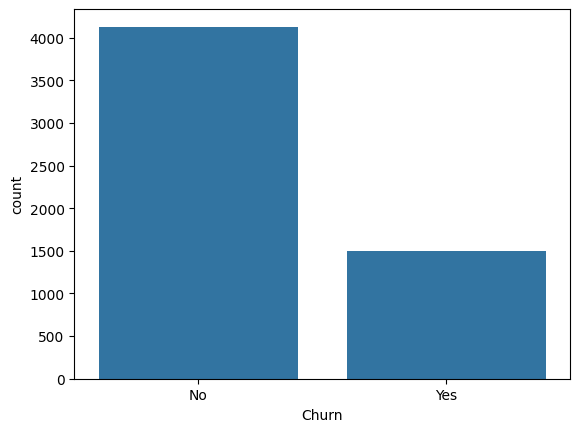

In [8]:
sns.countplot(x='Churn',data=train_df)
plt.show()

### Categorical Distribution

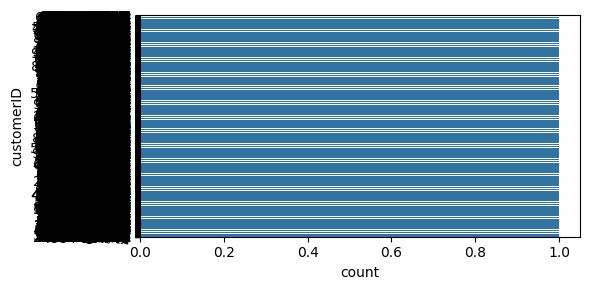

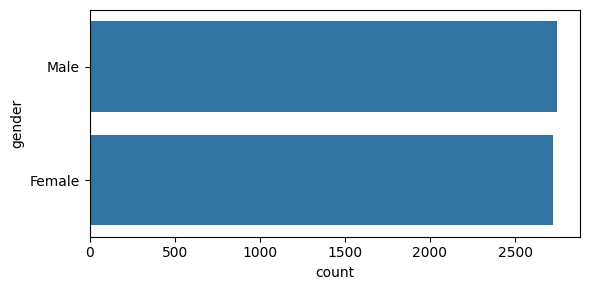

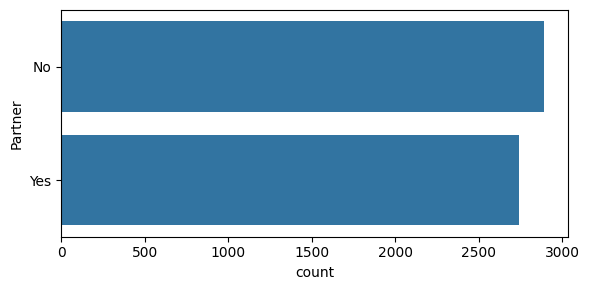

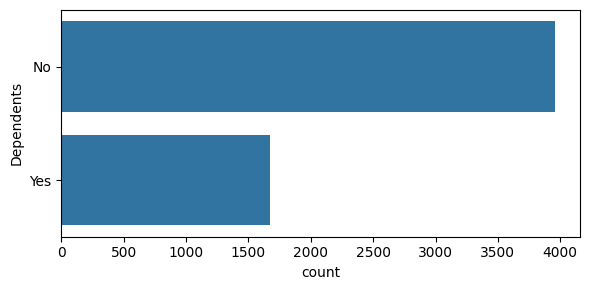

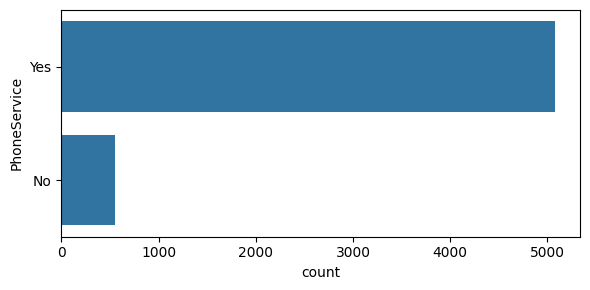

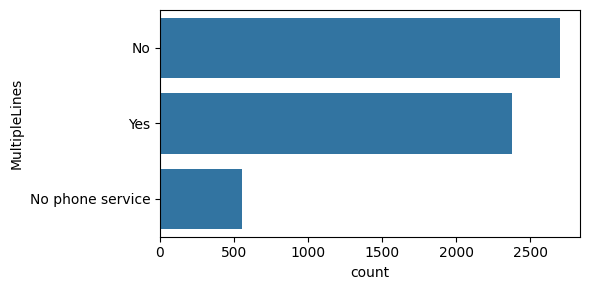

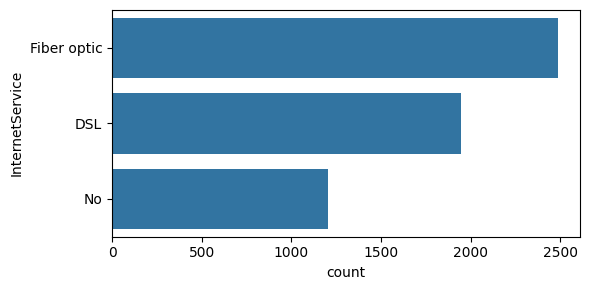

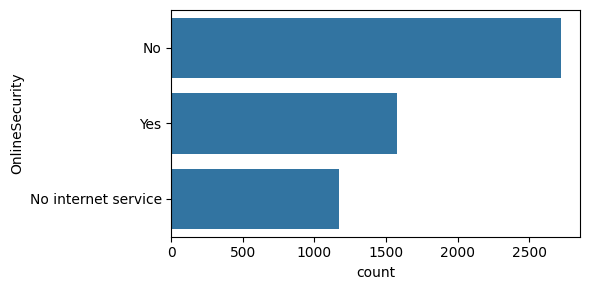

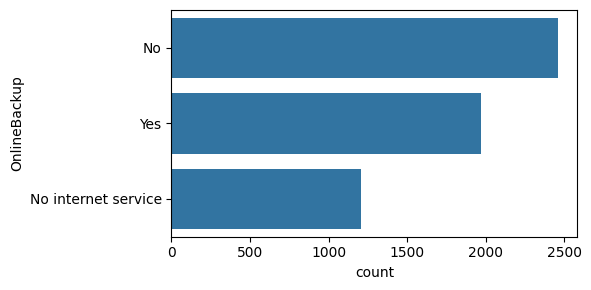

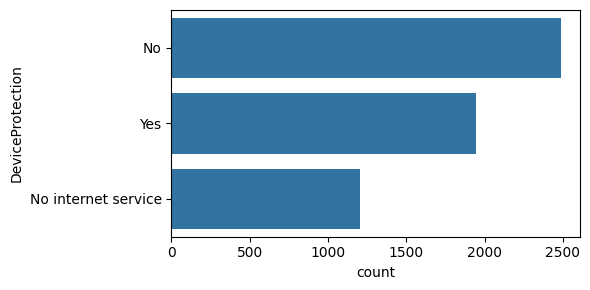

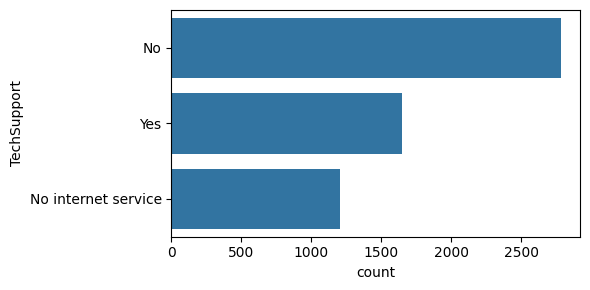

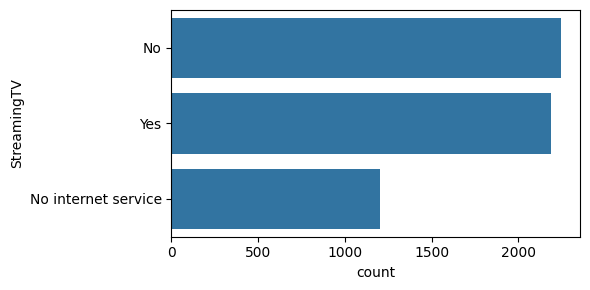

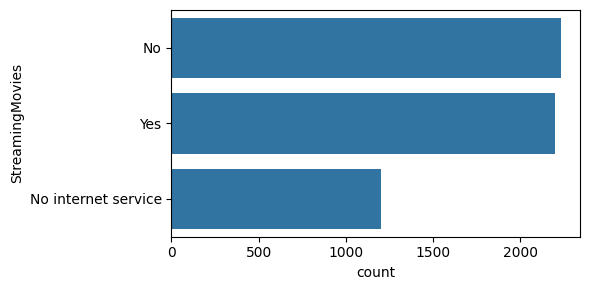

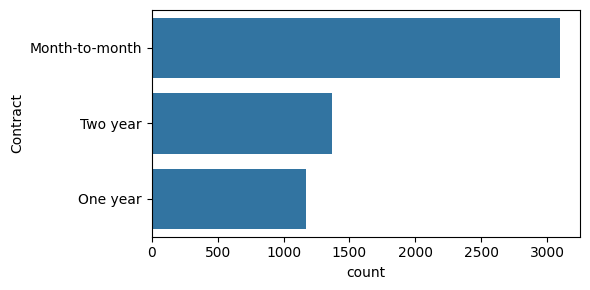

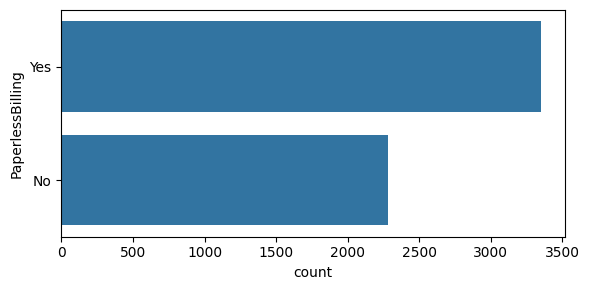

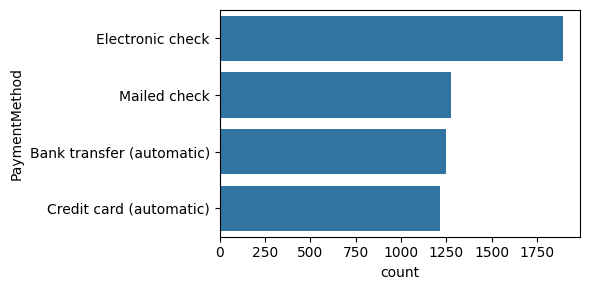

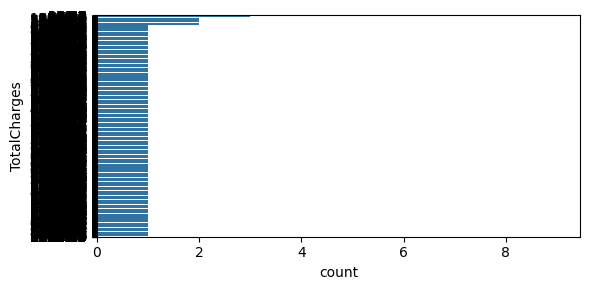

In [9]:
for col in train_df.select_dtypes(include='object').columns:
    if col!='Churn':
        plt.figure(figsize=(6,3));sns.countplot(y=col,data=train_df,order=train_df[col].value_counts().index);plt.tight_layout();plt.show()

### Numerical Distribution

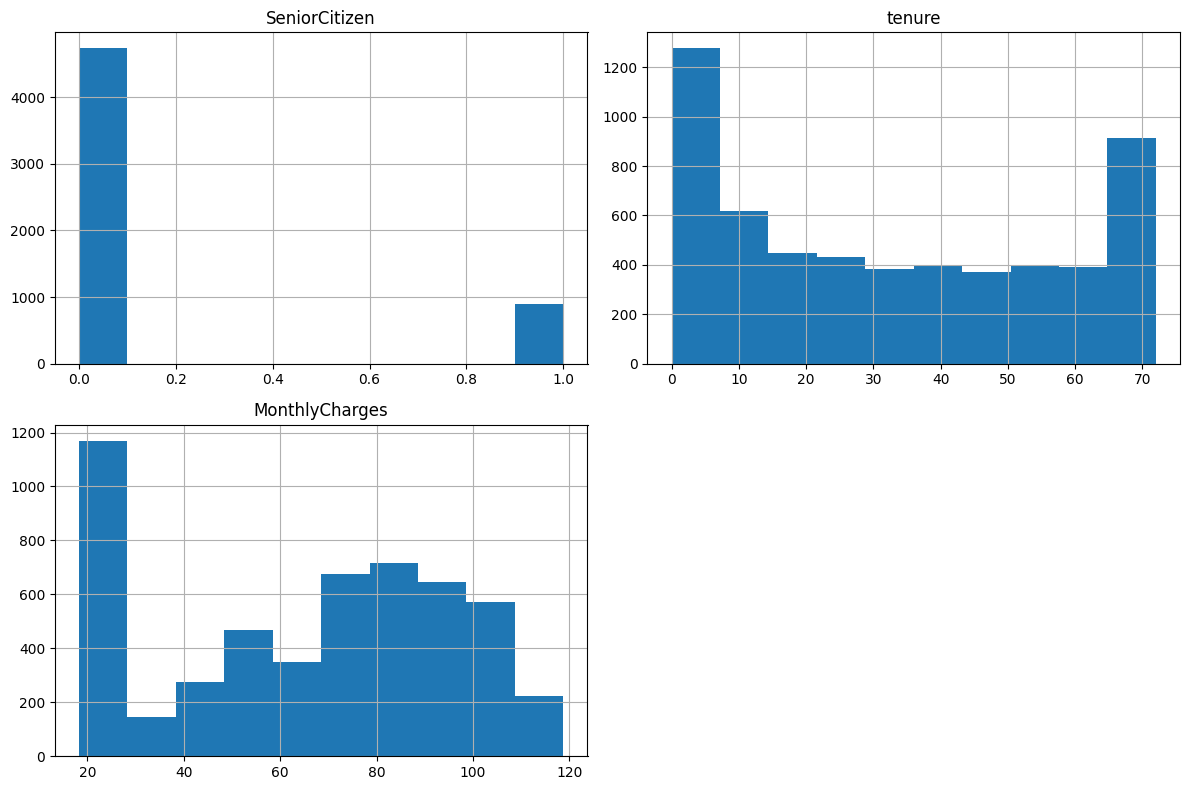

In [10]:
train_df.hist(figsize=(12,8));plt.tight_layout();plt.show()

### Correlation

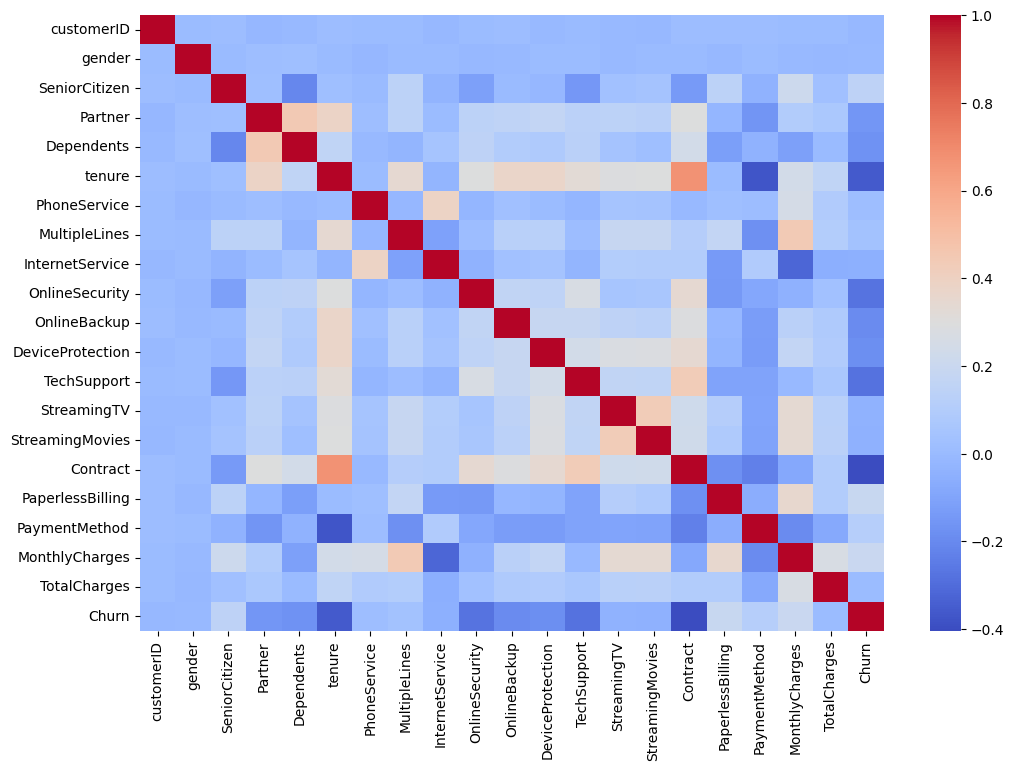

In [11]:
tmp=train_df.copy()
for c in tmp.select_dtypes(include='object').columns:
    tmp[c]=LabelEncoder().fit_transform(tmp[c].astype(str))
plt.figure(figsize=(12,8));sns.heatmap(tmp.corr(),cmap='coolwarm');plt.show()

### Outliers

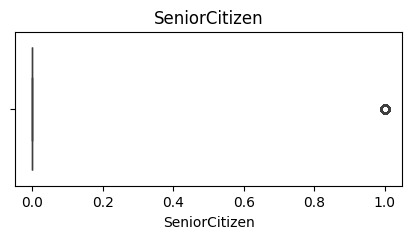

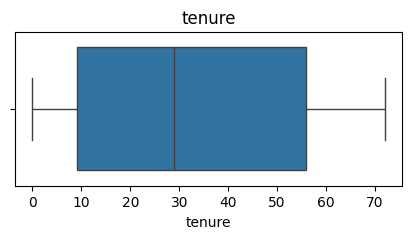

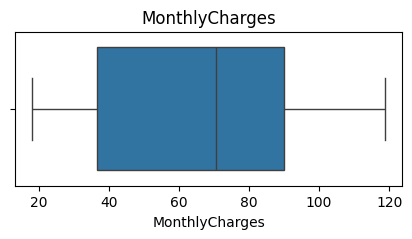

In [12]:
num=train_df.select_dtypes(include=np.number).columns
for c in num:
    plt.figure(figsize=(5,2));sns.boxplot(x=train_df[c]);plt.title(c);plt.show()

## Data Preprocessing

In [13]:
df=train_df.copy()

# Remove identifier
if 'CustomerID' in df.columns:
    df=df.drop(columns='CustomerID')

# Encode target
df['Churn']=df['Churn'].map({'Yes':1,'No':0})

X=df.drop('Churn',axis=1)
y=df['Churn']

cat=X.select_dtypes(include='object').columns
num=X.select_dtypes(exclude='object').columns

numeric_pipeline=Pipeline([
('imputer',SimpleImputer(strategy='median')),
('scaler',StandardScaler())
])

categorical_pipeline=Pipeline([
('imputer',SimpleImputer(strategy='most_frequent')),
('encoder',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor=ColumnTransformer([
('num',numeric_pipeline,num),
('cat',categorical_pipeline,cat)
])

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


## Feature Engineering

In [14]:
X_train=X_train.copy()
X_test=X_test.copy()

if {'Tenure','MonthlyCharges'}.issubset(X_train.columns):
    X_train['CustomerLifetimeValue']=X_train['Tenure']*X_train['MonthlyCharges']
    X_test['CustomerLifetimeValue']=X_test['Tenure']*X_test['MonthlyCharges']

if {'Tenure','Contract'}.issubset(X_train.columns):
    X_train['TenureContract']=X_train['Tenure'].astype(str)+'_'+X_train['Contract'].astype(str)
    X_test['TenureContract']=X_test['Tenure'].astype(str)+'_'+X_test['Contract'].astype(str)

# Rebuild feature lists
cat=X_train.select_dtypes(include='object').columns
num=X_train.select_dtypes(exclude='object').columns

preprocessor=ColumnTransformer([
('num',numeric_pipeline,num),
('cat',categorical_pipeline,cat)
])


## Model Development

Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.88      0.87       826
           1       0.64      0.57      0.60       301

    accuracy                           0.80      1127
   macro avg       0.75      0.73      0.73      1127
weighted avg       0.79      0.80      0.80      1127



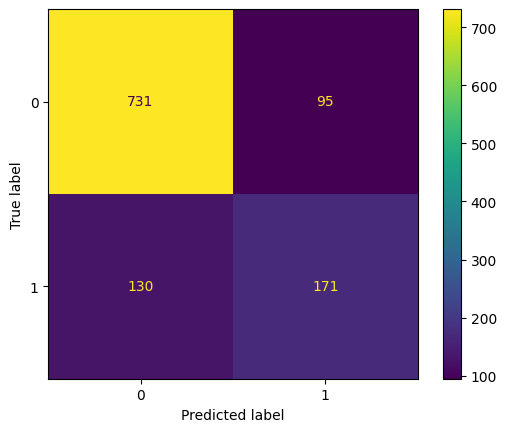

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       826
           1       0.67      0.48      0.56       301

    accuracy                           0.80      1127
   macro avg       0.75      0.69      0.71      1127
weighted avg       0.78      0.80      0.78      1127



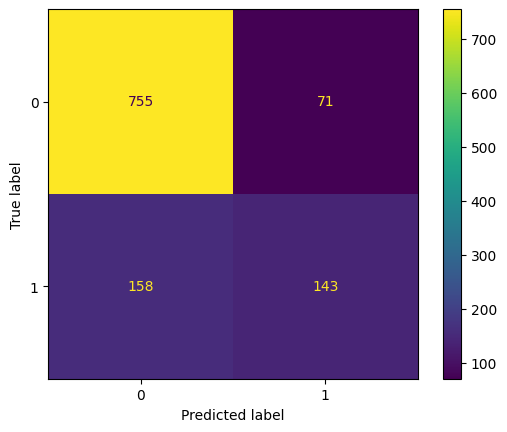

Gradient Boosting
              precision    recall  f1-score   support

           0       0.84      0.91      0.87       826
           1       0.67      0.53      0.60       301

    accuracy                           0.81      1127
   macro avg       0.76      0.72      0.73      1127
weighted avg       0.80      0.81      0.80      1127



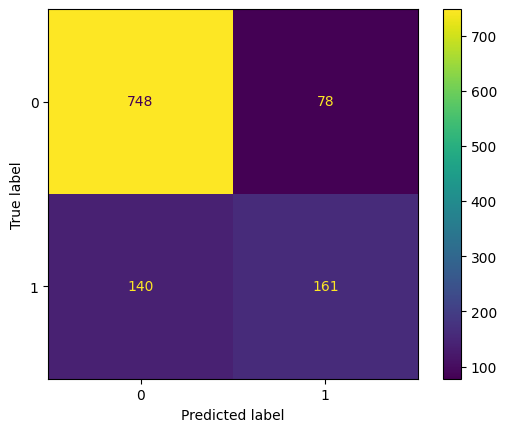

,Model,Accuracy,ROC_AUC
2,Gradient Boosting,0.806566,0.848926
0,Logistic Regression,0.800355,0.845048
1,Random Forest,0.796806,0.836427


In [15]:
models={
'Logistic Regression':LogisticRegression(max_iter=1000),
'Random Forest':RandomForestClassifier(random_state=42),
'Gradient Boosting':GradientBoostingClassifier(random_state=42)
}

results=[]

for name,model in models.items():
    pipe=Pipeline([
        ('prep',preprocessor),
        ('model',model)
    ])
    pipe.fit(X_train,y_train)
    pred=pipe.predict(X_test)
    acc=accuracy_score(y_test,pred)
    try:
        prob=pipe.predict_proba(X_test)[:,1]
        auc=roc_auc_score(y_test,prob)
    except:
        auc=None
    results.append([name,acc,auc])
    print(name)
    print(classification_report(y_test,pred))
    ConfusionMatrixDisplay.from_predictions(y_test,pred)
    plt.show()

results_df=pd.DataFrame(results,columns=['Model','Accuracy','ROC_AUC'])
results_df.sort_values('Accuracy',ascending=False)


## Hyperparameter Tuning

In [16]:
param_grid={
'model__n_estimators':[100,200],
'model__max_depth':[5,10,None]
}

rf_pipe=Pipeline([
('prep',preprocessor),
('model',RandomForestClassifier(random_state=42))
])

grid=GridSearchCV(rf_pipe,param_grid,cv=5,scoring='accuracy')
grid.fit(X_train,y_train)

print('Best Parameters:',grid.best_params_)
print('Best CV Score:',grid.best_score_)

best_model=grid.best_estimator_
pred=best_model.predict(X_test)
print(classification_report(y_test,pred))


Best Parameters: {'model__max_depth': None, 'model__n_estimators': 100}
Best CV Score: 0.7925424079182775
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       826
           1       0.67      0.48      0.56       301

    accuracy                           0.80      1127
   macro avg       0.75      0.69      0.71      1127
weighted avg       0.78      0.80      0.78      1127



## Conclusion
- Summarize EDA findings.
- Mention the best-performing model.
- Discuss important features.
- Suggest customer retention strategies based on the predictions.